# 计算背鳍清晰度

In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from blur_detector_torch import BlurDetector
from matplotlib import pyplot as plt

import image_grid

In [2]:
blur_detector = BlurDetector("models/blur_detection_resnet101_final.pth")

已加载模型: models/blur_detection_resnet101_final.pth


In [12]:
root_dir = "/media/filming/2025-白海豚/20240825-JM_02-1/"
METAINFO_CSV = root_dir + "/FIN_METAINFO.csv"

In [13]:
fin_dataset = pd.read_csv(METAINFO_CSV, index_col=0)

In [9]:
# test on one fin image
ret = blur_detector.predict(root_dir + "/" + fin_dataset.path[1])
print(ret)

{'class': 'blur', 'class_idx': 1, 'confidence': 0.9999862909317017, 'probabilities': {'clear': 1.3720710740017239e-05, 'blur': 0.9999862909317017}}


In [10]:
%%time
clearness_list = []
for i in tqdm(fin_dataset.path):
    ret = blur_detector.predict( root_dir + "/" + i)
    clearness_list.append( ret['probabilities']['clear'] )
fin_dataset["clearness"] = clearness_list
fin_dataset.to_csv(METAINFO_CSV)

100%|██████████| 4534/4534 [03:04<00:00, 24.55it/s]

CPU times: user 21min 53s, sys: 4.47 s, total: 21min 57s
Wall time: 3min 4s


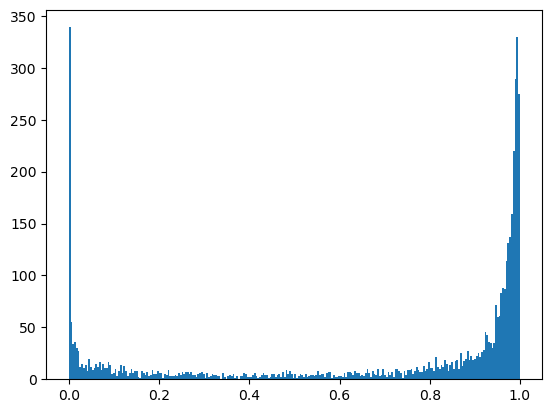

In [11]:
plt.hist(fin_dataset.clearness, bins=256)
plt.show()